# Notebook for generating plots of MNIST results 

In this notebook you can generate plots of saved uncertainty experiments. 

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from packaging.tags import platform_tags
from sklearn.metrics import roc_auc_score
from utils.visualization import *
import pickle
from glob import glob
import seaborn as sns
from pathlib import Path
import os


In [20]:
root = RESULTS_DIR = Path.cwd().parent / 'results'
experiment = 'mnist_blur'

newest_date = max(
    (d for d in os.scandir(root) if d.is_dir()),
    key=lambda d: d.stat().st_mtime
).name
newest_date = "2026-06-03"

newest_time = max(
    (d for d in os.scandir(root/newest_date/experiment) if d.is_dir()),
    key=lambda d: d.stat().st_mtime
).name

results_dir = root/newest_date/experiment/newest_time
print(f"Loading newest {experiment} results.")
print(f"Loading results from: {results_dir}")



Loading newest mnist_blur results.
Loading results from: /Users/sarasterlie/uncertainty-benchmark/results/2026-06-03/mnist_blur/11-26-12


In [21]:
legened_map = {
    'mc_dropout': 'MC Dropout',
    'ensemble': 'Deep Ensemble',
    'swag': 'SWAG',
    'laplace_approximation': 'Laplace Approximation',
    'ddu': 'DDU',
    'TTA': 'Test-Time Augmentation',
    'het_xl': 'HET-XL',
    'entropy': 'Entropy',
}
methods = {
    'epistemic_uncertainty': ["mc_dropout", "ensemble", "swag", "laplace_approximation", "ddu", "het_xl"],
    'aleatoric_uncertainty':["mc_dropout", "ensemble", "swag", "laplace_approximation", "ddu", "TTA", "het_xl"],
    'total_uncertainty': ["mc_dropout", "ensemble", "swag", "laplace_approximation", "ddu", "TTA", "het_xl", "entropy"]
}

colors = sns.color_palette("tab10", len(legened_map.values()))
palette_dict = dict(zip(legened_map.values(), colors))


def plot_uncertainty_line_plot(methods, order, experiment):
    fig, ax = plt.subplots(1,3, figsize=(25,8))
    fig.suptitle(experiment, fontsize=20)
    sns.set_style('white')
    for i, k in enumerate(['total_uncertainty', 'aleatoric_uncertainty', 'epistemic_uncertainty']):
        rows = []
        for method in methods[k]:
            for distortion in order:
                with open(f'{results_dir}/{method}/ood_uncertainty_{distortion}.pkl', 'rb') as f:
                    data = pickle.load(f)
                    rows.append({
                        'Uncertainty Score': data[k].numpy(),
                        'Ambiguity Level': distortion,
                        'method': legened_map[method]
                    })
    
        res = pd.DataFrame(rows).explode('Uncertainty Score').reset_index(drop=True)
        sns.lineplot(x="Ambiguity Level", y="Uncertainty Score", data=res, hue='method', ax=ax[i], palette=palette_dict,)
        ax[i].set_title(k)
    return plt

## Aleatoric MINST

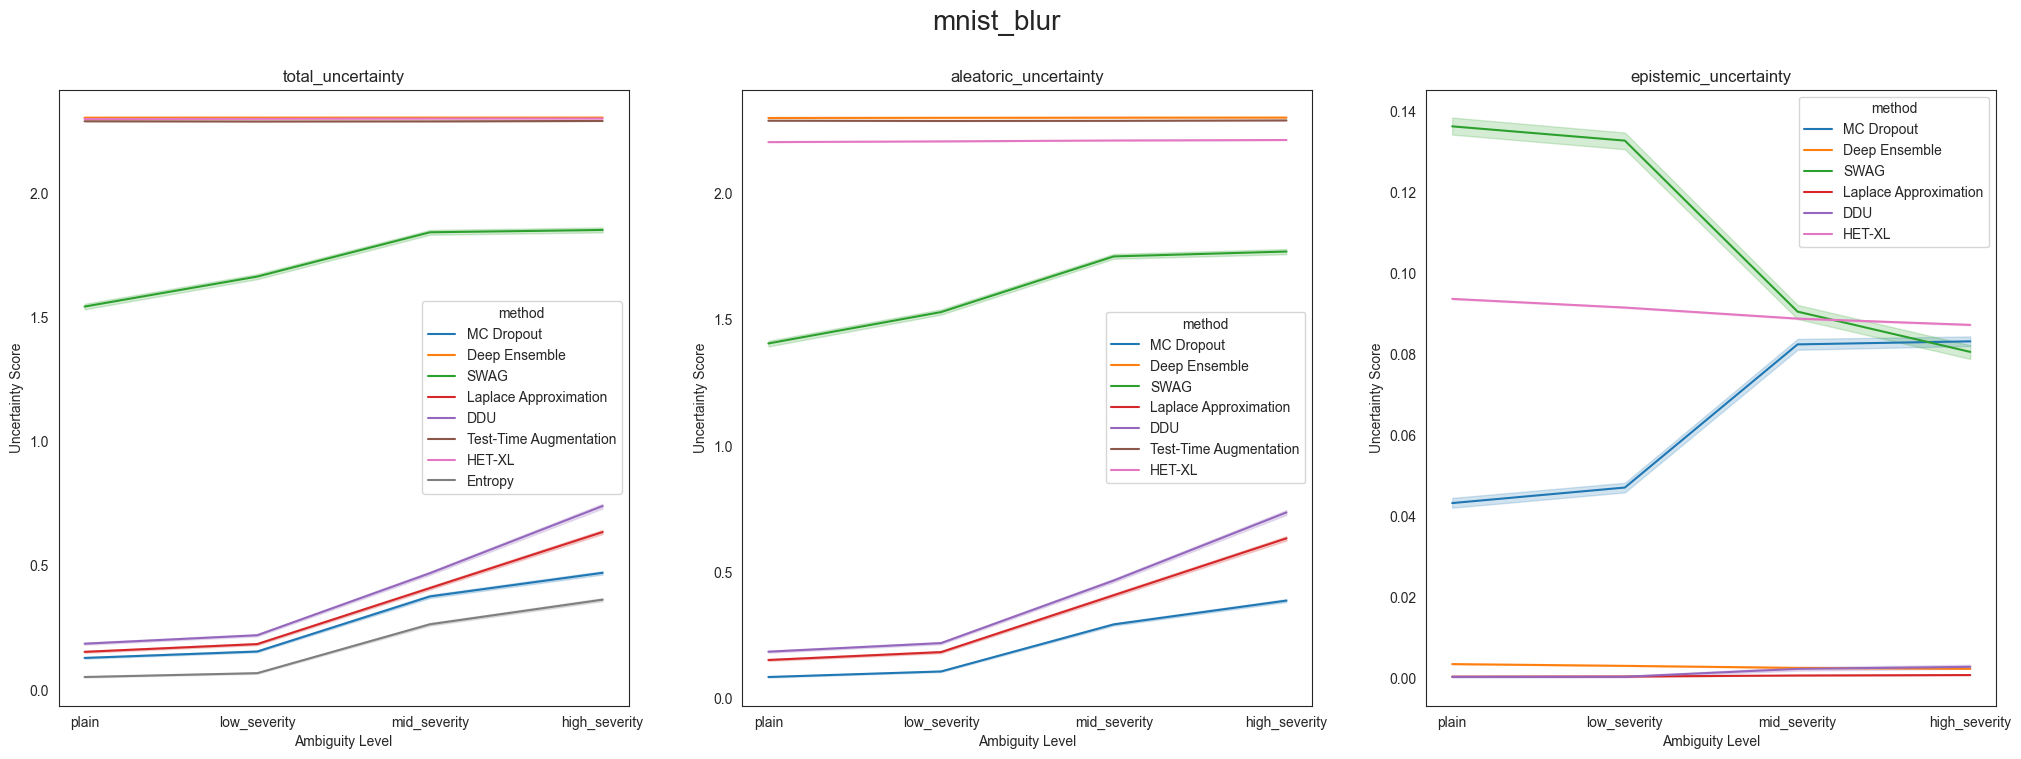

In [22]:
# plot combined uncertainty for mnist blur
order_mnist_blur = ['plain', 'low_severity', 'mid_severity', 'high_severity']
mnist_blur_plt = plot_uncertainty_line_plot(methods, order_mnist_blur, experiment)

mnist_blur_plt.show()


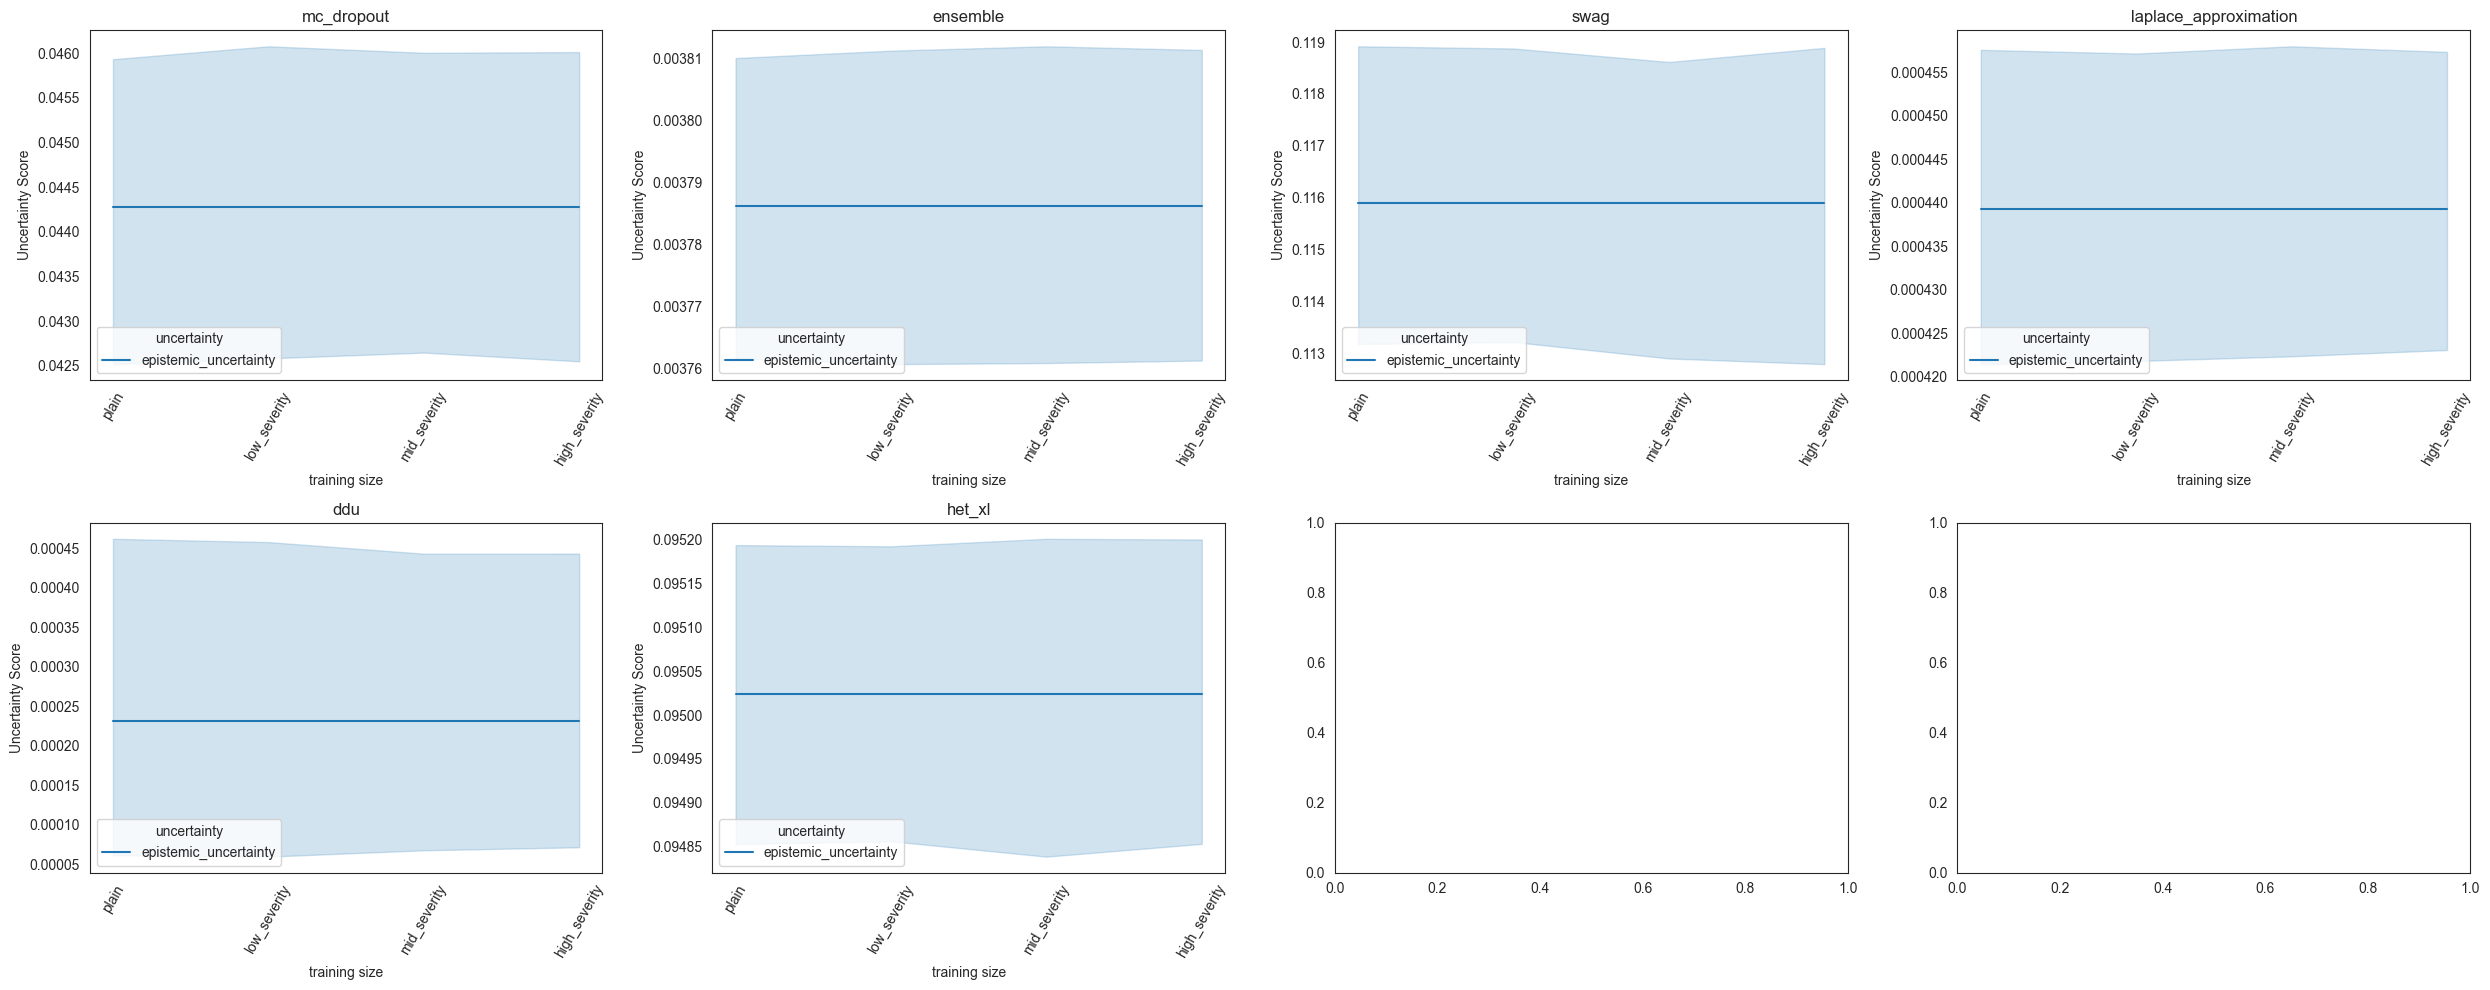

In [29]:
order = order_mnist_blur
fig, ax = plt.subplots(2, 4, figsize=(25, 10))

for i, m in enumerate(methods['epistemic_uncertainty']):
    rows = []
    for distortion in order:
        data = pickle.load(open(results_dir / m / f'valid_uncertainties.pkl', 'rb'))
        for u_type in ['epistemic_uncertainty']:
            rows.append({
            'uncertainty': u_type,
            'Uncertainty Score': data[u_type].numpy(),
            'training size': distortion,
            })
        res = pd.DataFrame(rows).explode('Uncertainty Score').reset_index(drop=True)
    sns.lineplot(x="training size", y="Uncertainty Score", data=res, hue='uncertainty', ax=ax[i//4, i%4])
    ax[i//4, i%4].tick_params(axis='x', rotation=60)
    ax[i//4, i%4].set_title(m)

plt.tight_layout()
plt.savefig(Path.cwd().parent / 'plots' / 'epistemic_trend.pdf')
plt.show()

In [ ]:
# plot combined uncertainty for mnist fracture 
order_mnist_fracture = 10
mnist_fracture_plt = plot_uncertainty_line_plot(methods, order_mnist_fracture, experiment)

mnist_fracture_plt.show()